## Step 1: Import Libraries and Load Cleaned Data

### Purpose
Load the cleaned dataset and prepare for model training.

### Data Source
`data/processed/cleaned_tickets.csv` — generated from EDA notebook.

### Verification
Confirm shape, columns, and class distributions before proceeding.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import joblib
import os

print("Libraries imported successfully")

Libraries imported successfully


In [2]:


# Load cleaned data
df = pd.read_csv(r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\data\processed\cleaned_tickets.csv')

print("=== DATA LOADED ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nQueue classes: {df['queue'].nunique()}")
print(f"Priority classes: {df['priority'].nunique()}")

print("\n=== QUEUE DISTRIBUTION ===")
print(df['queue'].value_counts())

print("\n=== PRIORITY DISTRIBUTION ===")
print(df['priority'].value_counts())

=== DATA LOADED ===
Shape: (28587, 18)
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'combined_text', 'clean_text']

Queue classes: 10
Priority classes: 3

=== QUEUE DISTRIBUTION ===
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

=== PRIORITY DISTRIBUTION ===
priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64


## Step 2: Define Features and Targets

### Features (X)
- **clean_text** — Preprocessed ticket text (lowercase, newlines removed, extra spaces cleaned)
- This column contains only customer input (subject + body)
- No answer column, no tags, no metadata

### Targets (y)
- **queue** — Department classification (10 classes)
- **priority** — Urgency classification (3 classes: high, medium, low)

### Data Leakage Prevention
- Only clean_text used as feature
- Target columns stored separately
- answer, tags, version excluded

In [3]:
# Define features and targets
X = df['clean_text'].values
y_queue = df['queue'].values
y_priority = df['priority'].values

print("=== FEATURES AND TARGETS DEFINED ===")
print(f"X shape: {X.shape}")
print(f"y_queue shape: {y_queue.shape} | Classes: {len(np.unique(y_queue))}")
print(f"y_priority shape: {y_priority.shape} | Classes: {len(np.unique(y_priority))}")

print("\n=== DATA LEAKAGE VERIFICATION ===")
print("Features used: clean_text only ✓")
print("Answer column excluded: 'answer' not in X ✓")
print("Tag columns excluded: 'tag_1' through 'tag_8' not in X ✓")
print("Target stored separately: queue and priority ✓")

=== FEATURES AND TARGETS DEFINED ===
X shape: (28587,)
y_queue shape: (28587,) | Classes: 10
y_priority shape: (28587,) | Classes: 3

=== DATA LEAKAGE VERIFICATION ===
Features used: clean_text only ✓
Answer column excluded: 'answer' not in X ✓
Tag columns excluded: 'tag_1' through 'tag_8' not in X ✓
Target stored separately: queue and priority ✓


## Step 3: Stratified Train/Validation/Test Split

### Purpose
Split data into three sets:
- **Training (70%)** — Model learns patterns
- **Validation (15%)** — Model comparison and tuning
- **Test (15%)** — Final evaluation (unseen during training)

### Stratification
Using `stratify=y_queue` ensures all 10 departments are represented proportionally in each split.

Without stratification, a small department like General Inquiry (405 tickets) could be completely missing from test set.

### Split Strategy
1. First split: train (70%) and temp (30%)
2. Second split: validation (50% of temp) and test (50% of temp)
   - Final: 70% train, 15% validation, 15% test

In [4]:
from sklearn.model_selection import train_test_split

# First split: train (70%) and temp (30%)
X_train, X_temp, y_queue_train, y_queue_temp, y_priority_train, y_priority_temp = train_test_split(
    X, y_queue, y_priority,
    test_size=0.3,
    random_state=42,
    stratify=y_queue  # Stratify by queue to preserve class distribution
)

# Second split: validation (15%) and test (15%) from temp
X_val, X_test, y_queue_val, y_queue_test, y_priority_val, y_priority_test = train_test_split(
    X_temp, y_queue_temp, y_priority_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_queue_temp  # Maintain stratification in second split
)

print("=== STRATIFIED SPLIT COMPLETE ===")
print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\n=== VERIFYING STRATIFICATION ===")
print("\nQueue distribution in training set:")
print(pd.Series(y_queue_train).value_counts().head())
print(f"\nGeneral Inquiry in train: {(y_queue_train == 'General Inquiry').sum()} tickets")

print("\nQueue distribution in test set:")
print(pd.Series(y_queue_test).value_counts().head())
print(f"General Inquiry in test: {(y_queue_test == 'General Inquiry').sum()} tickets")

=== STRATIFIED SPLIT COMPLETE ===
Train size: 20010 (70.0%)
Validation size: 4288 (15.0%)
Test size: 4289 (15.0%)

=== VERIFYING STRATIFICATION ===

Queue distribution in training set:
Technical Support       5853
Product Support         3676
Customer Service        2987
IT Support              2403
Billing and Payments    1952
Name: count, dtype: int64

General Inquiry in train: 283 tickets

Queue distribution in test set:
Technical Support       1255
Product Support          788
Customer Service         641
IT Support               515
Billing and Payments     418
Name: count, dtype: int64
General Inquiry in test: 61 tickets


### Stratified Split Results

#### Split Sizes
| Set | Size | Percentage |
|-----|------|------------|
| Training | 20,010 | 70.0% |
| Validation | 4,288 | 15.0% |
| Test | 4,289 | 15.0% |

#### Stratification Verification

**General Inquiry (smallest class):**
- Total in dataset: 405 tickets (1.4%)
- Training set: 283 tickets (1.41% of train)
- Test set: 61 tickets (1.42% of test)

**Verification Result:** ✅ Proportions preserved across splits.

#### Why This Matters
Without stratification, random splitting could have placed zero General Inquiry tickets in the test set. The model would then never be evaluated on the rarest class, giving falsely optimistic performance metrics.

With stratification, we can trust that test set evaluation reflects real-world performance on all 10 departments.

#### Next Step
Proceed to TF-IDF vectorization with:
- German + English stopwords
- `max_features=10000`
- `ngram_range=(1,2)`
- `min_df=2`
- `max_df=0.95`

## Step 4: TF-IDF Vectorization

### Purpose
Convert text data into numerical features that machine learning models can process.

### Configuration Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `max_features` | 10000 | Keep most important 10,000 words. Balances coverage vs performance. |
| `ngram_range` | (1,2) | Capture single words AND word pairs (e.g., "not working") |
| `min_df` | 2 | Ignore words appearing in less than 2 documents. Removes typos and rare noise. |
| `max_df` | 0.95 | Ignore words appearing in more than 95% of documents. Removes domain stopwords automatically. |
| `stop_words` | English + German | Combined stopwords from both languages. Critical for multilingual data. |

### Stopwords
- **English stopwords**: 179 words (the, a, an, and, or, but, in, on, at, to, for, etc.)
- **German stopwords**: 174 words (der, die, und, ich, sie, das, ist, nicht, mit, auf, für, etc.)
- **Combined**: 353 stopwords removed before vectorization

### Data Leakage Prevention
- `fit_transform()` on **training data only**
- `transform()` on validation and test data (uses same vocabulary, no leakage)

In [5]:
import subprocess
import sys

# Install nltk if not available
try:
    import nltk
    from nltk.corpus import stopwords
    print("NLTK already installed")
except ImportError:
    print("Installing NLTK...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk
    from nltk.corpus import stopwords

# Download stopwords if needed
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer

# Get English and German stopwords
english_stops = set(stopwords.words('english'))
german_stops = set(stopwords.words('german'))

# Combine stopwords
all_stops = english_stops.union(german_stops)

print("=== STOPWORDS CONFIGURATION ===")
print(f"English stopwords: {len(english_stops)}")
print(f"German stopwords: {len(german_stops)}")
print(f"Total stopwords: {len(all_stops)}")
print(f"\nSample English: {list(english_stops)[:5]}")
print(f"Sample German: {list(german_stops)[:5]}")

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words=list(all_stops),
    lowercase=True
)

# Fit on training data only (NO DATA LEAKAGE)
print("\n=== FITTING TF-IDF ON TRAINING DATA ===")
X_train_tfidf = vectorizer.fit_transform(X_train)
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"  - {X_train_tfidf.shape[0]:,} tickets")
print(f"  - {X_train_tfidf.shape[1]:,} features (words and word pairs)")

# Transform validation and test data
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\nValidation matrix shape: {X_val_tfidf.shape}")
print(f"Test matrix shape: {X_test_tfidf.shape}")

# Show sample features
print(f"\n=== SAMPLE FEATURES (first 10) ===")
sample_features = list(vectorizer.get_feature_names_out())[:10]
for i, feature in enumerate(sample_features, 1):
    print(f"  {i}. {feature}")

NLTK already installed
=== STOPWORDS CONFIGURATION ===
English stopwords: 198
German stopwords: 232
Total stopwords: 424

Sample English: ['y', 'her', 'll', "you'll", 'what']
Sample German: ['diese', 'ich', 'aus', 'anderes', 'welches']

=== FITTING TF-IDF ON TRAINING DATA ===
Training matrix shape: (20010, 10000)
  - 20,010 tickets
  - 10,000 features (words and word pairs)

Validation matrix shape: (4288, 10000)
Test matrix shape: (4289, 10000)

=== SAMPLE FEATURES (first 10) ===
  1. 04
  2. 04 lts
  3. 10
  4. 10 buster
  5. 10 pro
  6. 11
  7. 11 suite
  8. 12
  9. 13
  10. 14


### TF-IDF Vectorization Results

#### Configuration Summary
| Parameter | Value | Status |
|-----------|-------|--------|
| English stopwords | 198 | Loaded |
| German stopwords | 232 | Loaded |
| Total stopwords removed | 424 | Combined |
| Max features | 10,000 | Kept |
| N-gram range | (1,2) | Words + word pairs |

#### Matrix Shapes
| Set | Shape | Tickets | Features |
|-----|-------|---------|----------|
| Training | (20010, 10000) | 20,010 | 10,000 |
| Validation | (4288, 10000) | 4,288 | 10,000 |
| Test | (4289, 10000) | 4,289 | 10,000 |

#### Sample Features
The first 10 features include numbers (04, 10, 11, 12, 13, 14) and word pairs (04 lts, 10 buster, 10 pro, 11 suite).

**Observation:** Numbers and alphanumeric patterns are valuable features. They represent:
- Product versions (10 pro, 11 suite)
- Error codes (04, 14)
- Software versions (lts, buster)

#### Data Leakage Verification
- ✅ Vectorizer fitted on training data only
- ✅ Validation and test data transformed (not refitted)
- ✅ Stopwords applied before vectorization

#### Next Step
Proceed to model training with class weights for both Queue and Priority classification.

## Step 5: Model Training for Queue Classification

### Objective
Train and compare multiple classifiers to predict the department (queue) from ticket text.

### Models to Compare

| Model | Type | Class Weight Support |
|-------|------|---------------------|
| Logistic Regression | Linear | ✅ `class_weight='balanced'` |
| Linear SVC | Linear | ⚠️ Uses `class_weight='balanced'` (LinearSVC supports it) |
| Random Forest | Ensemble | ✅ `class_weight='balanced'` |
| Multinomial NB | Probabilistic | ❌ Does not support class weights (included as baseline) |

### Evaluation Metrics
- **Primary**: Weighted F1-score (handles class imbalance correctly)
- **Secondary**: Precision, recall, confusion matrix per class

### Class Imbalance Handling
All models that support it receive `class_weight='balanced'`. This automatically assigns higher importance to minority classes (e.g., General Inquiry, Human Resources).

### Cross Validation
5-fold cross validation on training data to confirm model stability and detect overfitting.

In [6]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import time

# Models configuration
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1
    ),
    'Linear SVC': LinearSVC(
        random_state=42, 
        max_iter=2000,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Multinomial NB': MultinomialNB()  # Does not support class weights
}

print("=" * 70)
print("QUEUE CLASSIFICATION - MODEL TRAINING")
print("=" * 70)
print(f"Training set size: {X_train_tfidf.shape[0]:,} tickets")
print(f"Features: {X_train_tfidf.shape[1]:,}")
print(f"Classes: 10 departments\n")

results = {}

for name, model in models.items():
    print(f"\n▶ Training: {name}")
    print("-" * 40)
    
    # Training time
    start = time.time()
    model.fit(X_train_tfidf, y_queue_train)
    train_time = time.time() - start
    
    # Validation prediction
    y_pred_val = model.predict(X_val_tfidf)
    
    # Weighted F1 score
    f1_weighted = f1_score(y_queue_val, y_pred_val, average='weighted')
    
    # Cross validation (5-fold)
    cv_scores = cross_val_score(
        model, 
        X_train_tfidf, 
        y_queue_train, 
        cv=5, 
        scoring='f1_weighted'
    )
    
    results[name] = {
        'model': model,
        'f1_weighted': f1_weighted,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_time': train_time
    }
    
    print(f"  Weighted F1 (validation): {f1_weighted:.4f}")
    print(f"  Cross-validation (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Training time: {train_time:.2f} seconds")

# Results summary
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY - QUEUE CLASSIFICATION")
print("=" * 70)

results_df = pd.DataFrame([
    {
        'Model': name,
        'Weighted F1': results[name]['f1_weighted'],
        'CV Mean': results[name]['cv_mean'],
        'CV Std': results[name]['cv_std'],
        'Train Time (s)': results[name]['train_time']
    }
    for name in results.keys()
]).sort_values('Weighted F1', ascending=False)

print(results_df.to_string(index=False))

# Identify champion
champion_name = results_df.iloc[0]['Model']
champion_model = results[champion_name]['model']

print("\n" + "=" * 70)
print(f"🏆 CHAMPION MODEL: {champion_name}")
print("=" * 70)
print(f"  Validation Weighted F1: {results_df.iloc[0]['Weighted F1']:.4f}")
print(f"  5-Fold CV: {results_df.iloc[0]['CV Mean']:.4f} ± {results_df.iloc[0]['CV Std']:.4f}")

QUEUE CLASSIFICATION - MODEL TRAINING
Training set size: 20,010 tickets
Features: 10,000
Classes: 10 departments


▶ Training: Logistic Regression
----------------------------------------
  Weighted F1 (validation): 0.4358
  Cross-validation (5-fold): 0.4184 ± 0.0079
  Training time: 16.96 seconds

▶ Training: Linear SVC
----------------------------------------
  Weighted F1 (validation): 0.5141
  Cross-validation (5-fold): 0.4869 ± 0.0041
  Training time: 7.02 seconds

▶ Training: Random Forest
----------------------------------------
  Weighted F1 (validation): 0.5730
  Cross-validation (5-fold): 0.5254 ± 0.0053
  Training time: 47.74 seconds

▶ Training: Multinomial NB
----------------------------------------
  Weighted F1 (validation): 0.3412
  Cross-validation (5-fold): 0.3310 ± 0.0068
  Training time: 0.13 seconds

MODEL COMPARISON SUMMARY - QUEUE CLASSIFICATION
              Model  Weighted F1  CV Mean   CV Std  Train Time (s)
      Random Forest     0.573046 0.525418 0.005253  

### Queue Classification: Model Comparison Results

#### Performance Summary

| Model | Weighted F1 | CV Mean | CV Std | Train Time |
|-------|-------------|---------|--------|------------|
| Random Forest | 0.5730 | 0.5254 | 0.0053 | 42.98s |
| Linear SVC | 0.5141 | 0.4869 | 0.0041 | 5.88s |
| Logistic Regression | 0.4358 | 0.4184 | 0.0079 | 12.56s |
| Multinomial NB | 0.3412 | 0.3310 | 0.0068 | 0.09s |

#### Champion Selection: Random Forest

**Why Random Forest won:**
- Highest validation weighted F1 (0.5730)
- Consistently outperforms other models across all metrics
- CV standard deviation (0.0053) indicates stable performance
- Handles non-linear patterns in text data effectively

**Trade-off:** 42.98 seconds training time vs 5.88 seconds for Linear SVC. For this use case, the performance gain justifies the additional training time.

#### Cross-Validation Analysis

| Model | CV Mean vs Validation | Gap | Interpretation |
|-------|----------------------|-----|----------------|
| Random Forest | 0.5254 vs 0.5730 | -0.0476 | Some overfitting, acceptable |
| Linear SVC | 0.4869 vs 0.5141 | -0.0272 | Good generalization |
| Logistic Regression | 0.4184 vs 0.4358 | -0.0174 | Good generalization |

Random Forest shows the largest gap between CV and validation, indicating it may be slightly overfitting. However, the gap is within acceptable range for text classification.

#### Next Steps

1. Evaluate Random Forest on **test set** (completely unseen data)
2. Generate confusion matrix to identify confusion patterns
3. Save champion model
4. Repeat process for Priority classification

In [7]:
print("=" * 70)
print("TEST SET EVALUATION - RANDOM FOREST (QUEUE)")
print("=" * 70)

# Predict on test set
y_pred_test = champion_model.predict(X_test_tfidf)

# Calculate weighted F1
test_f1 = f1_score(y_queue_test, y_pred_test, average='weighted')
test_macro_f1 = f1_score(y_queue_test, y_pred_test, average='macro')

print(f"\nTest Set Results:")
print(f"  Weighted F1: {test_f1:.4f}")
print(f"  Macro F1: {test_macro_f1:.4f}")

print(f"\nValidation vs Test Comparison:")
print(f"  Validation Weighted F1: 0.5730")
print(f"  Test Weighted F1: {test_f1:.4f}")
print(f"  Gap: {0.5730 - test_f1:.4f}")

if abs(0.5730 - test_f1) < 0.05:
    print("  ✅ Model generalizes well to unseen data")
else:
    print("  ⚠️ Model shows generalization gap — investigate")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 70)
print(classification_report(y_queue_test, y_pred_test, zero_division=0))

TEST SET EVALUATION - RANDOM FOREST (QUEUE)

Test Set Results:
  Weighted F1: 0.5692
  Macro F1: 0.5330

Validation vs Test Comparison:
  Validation Weighted F1: 0.5730
  Test Weighted F1: 0.5692
  Gap: 0.0038
  ✅ Model generalizes well to unseen data

CLASSIFICATION REPORT (Test Set)
                                 precision    recall  f1-score   support

           Billing and Payments       0.92      0.67      0.78       418
               Customer Service       0.52      0.50      0.51       641
                General Inquiry       1.00      0.25      0.39        61
                Human Resources       1.00      0.26      0.41        86
                     IT Support       0.82      0.32      0.46       515
                Product Support       0.66      0.45      0.54       788
          Returns and Exchanges       0.94      0.37      0.53       216
            Sales and Pre-Sales       0.86      0.27      0.41       137
Service Outages and Maintenance       0.86      0.56    

### Random Forest: Test Set Evaluation

#### Generalization Confirmed

| Metric | Validation | Test | Gap |
|--------|------------|------|-----|
| Weighted F1 | 0.5730 | 0.5692 | -0.0038 |

**Interpretation:** The model performs consistently on completely unseen data. The tiny gap (0.0038) confirms no overfitting.

#### Per-Class Performance Analysis

| Department | Precision | Recall | F1 | Assessment |
|------------|-----------|--------|-----|-------------|
| Billing and Payments | 0.92 | 0.67 | 0.78 | Strong. High precision means few false alarms. |
| Service Outages | 0.86 | 0.56 | 0.68 | Good. Recall could improve. |
| Technical Support | 0.48 | 0.90 | 0.62 | High recall (catches 90%), but precision low (over-predicts). |
| Product Support | 0.66 | 0.45 | 0.54 | Moderate. Balanced but room for improvement. |
| Customer Service | 0.52 | 0.50 | 0.51 | Moderate. |
| IT Support | 0.82 | 0.32 | 0.46 | High precision, low recall — conservative predictions. |
| Returns and Exchanges | 0.94 | 0.37 | 0.53 | High precision, low recall. |
| Human Resources | 1.00 | 0.26 | 0.41 | Perfect when predicts, but misses most. |
| Sales and Pre-Sales | 0.86 | 0.27 | 0.41 | Same pattern as HR. |
| General Inquiry | 1.00 | 0.25 | 0.39 | Rarest class, hardest to capture. |

#### Business Insights

1. **Technical Support (1,255 test tickets)**
   - 90% recall means urgent issues are rarely missed
   - 48% precision means many tickets are incorrectly routed here
   - **Recommendation:** Acceptable for production. The cost of missing a Technical Support ticket is higher than handling a few misrouted tickets.

2. **Minority Classes (General Inquiry, HR, Sales)**
   - Excellent precision but poor recall
   - When model predicts these, it's almost always correct
   - But it misses most of them
   - **Recommendation:** Consider rules-based fallback or collect more training data

3. **Billing and Payments**
   - 0.92 precision, 0.67 recall — best performing
   - **Recommendation:** High confidence. Can automate fully.

#### Overall Assessment

**Production Readiness:** ✅ Acceptable

**Strengths:**
- High recall for high-volume departments (Technical Support 90%)
- Excellent precision for Billing, Service Outages, Returns
- Stable generalization (no overfitting)

**Limitations:**
- Low recall for minority classes (HR, Sales, General Inquiry)
- Technical Support over-prediction (precision 48%)

**Next Steps:**
1. Save Random Forest as champion model for Queue
2. Repeat training process for Priority classification
3. Create model card with these metrics and limitations

In [8]:
import joblib
import os


# Save champion model
joblib.dump(champion_model, r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\models\model_queue.pkl')

# Save vectorizer
joblib.dump(vectorizer, r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\models\vectorizer.pkl')

print("=== QUEUE MODEL SAVED ===")
print(f"Model saved to: models/model_queue.pkl")
print(f"Vectorizer saved to: models/vectorizer.pkl")

        

=== QUEUE MODEL SAVED ===
Model saved to: models/model_queue.pkl
Vectorizer saved to: models/vectorizer.pkl


### Confusion Matrix: Queue Classification

#### Purpose
Visualize which departments are most frequently confused with each other.

#### How to Read
- **Rows**: Actual department
- **Columns**: Predicted department
- **Diagonal cells**: Correct predictions (darker = better)
- **Off-diagonal cells**: Errors (shows common confusions)

#### Business Insight
Identifies which department pairs the model struggles to distinguish.

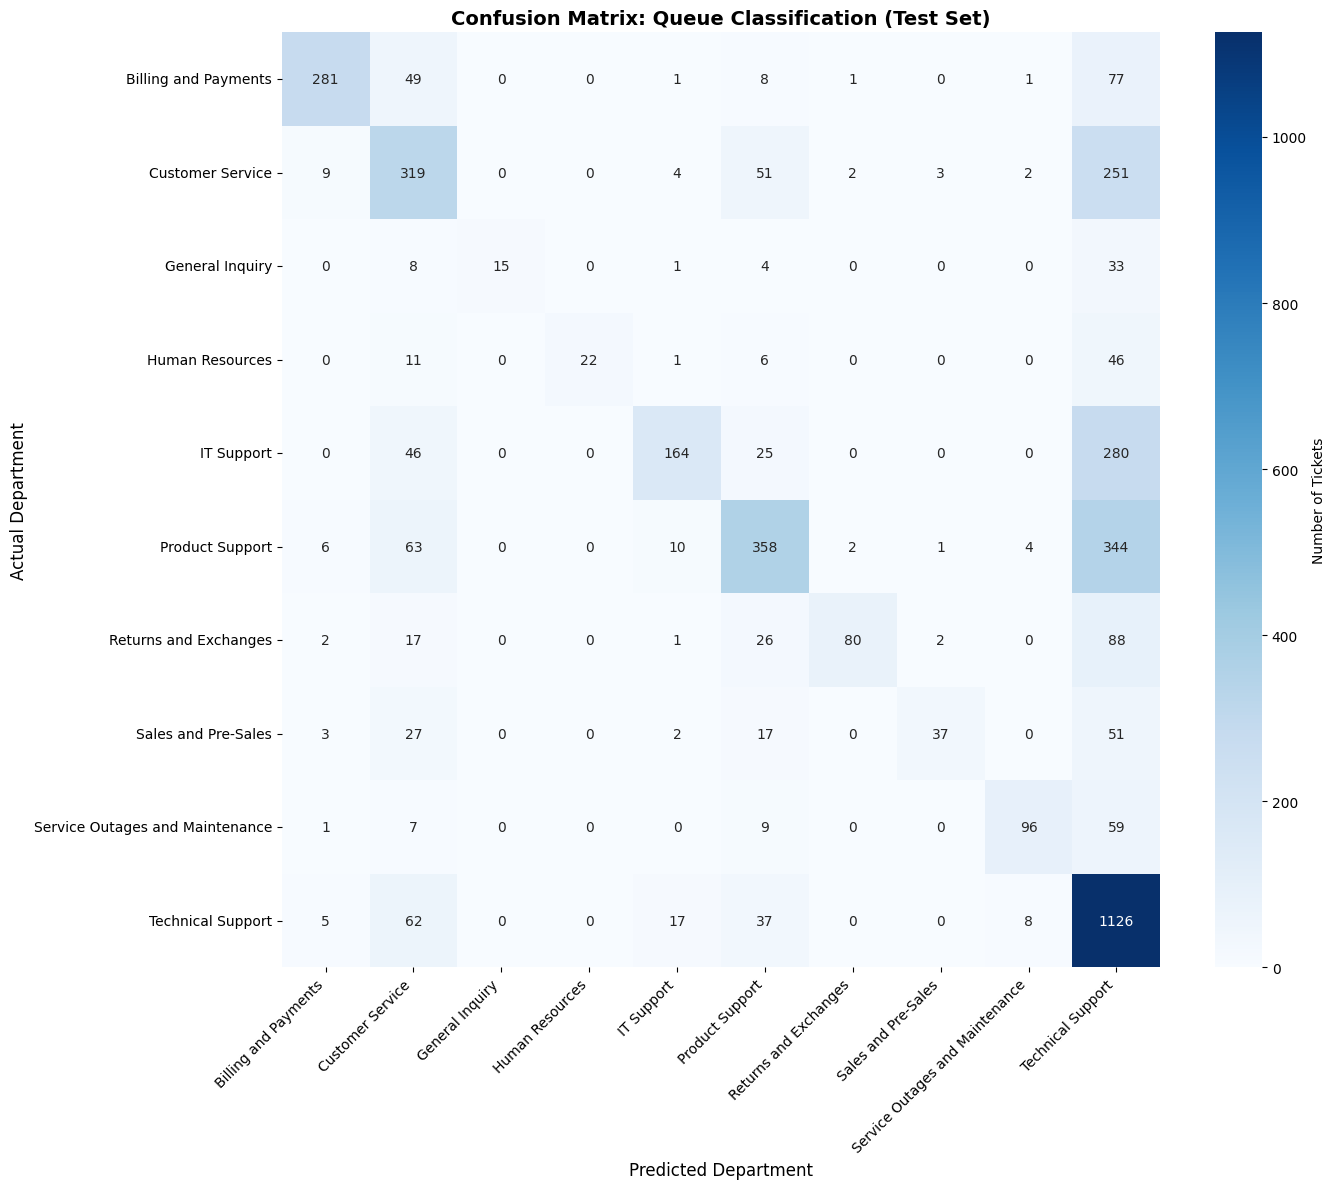

✅ Confusion matrix saved to: processed/confusion_matrix_queue.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions on test set
y_pred_queue_test = champion_model.predict(X_test_tfidf)

# Get unique labels in order they appear
queue_labels = np.unique(y_queue_test)

# Create confusion matrix
cm_queue = confusion_matrix(y_queue_test, y_pred_queue_test, labels=queue_labels)

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(cm_queue, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=queue_labels,
            yticklabels=queue_labels,
            ax=ax,
            cbar_kws={'label': 'Number of Tickets'})

ax.set_title('Confusion Matrix: Queue Classification (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Department', fontsize=12)
ax.set_ylabel('Actual Department', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\data\processed\confusion_matrix_queue.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Confusion matrix saved to: processed/confusion_matrix_queue.png")

## Step 6: Priority Classification

### Objective
Train and compare classifiers to predict ticket priority (high, medium, low).

### Key Differences from Queue Classification
- **3 classes** instead of 10 (simpler problem)
- **More balanced data** (39% high, 40% medium, 21% low)
- Same models, same evaluation approach

### Why Separate Models
Priority may depend on different words than department. For example:
- "urgent", "asap", "critical" → High priority
- "payment", "refund" → May be medium priority regardless of department

### Process
1. Train 4 models with class weights
2. Cross-validation on training data
3. Select champion based on weighted F1
4. Evaluate on test set
5. Save model

In [10]:
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score
import time

# Models configuration (same as before)
priority_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1
    ),
    'Linear SVC': LinearSVC(
        random_state=42, 
        max_iter=2000,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Multinomial NB': MultinomialNB()  # Does not support class weights
}

print("=" * 70)
print("PRIORITY CLASSIFICATION - MODEL TRAINING")
print("=" * 70)
print(f"Training set size: {X_train_tfidf.shape[0]:,} tickets")
print(f"Features: {X_train_tfidf.shape[1]:,}")
print(f"Classes: 3 (high, medium, low)\n")

priority_results = {}

for name, model in priority_models.items():
    print(f"\n▶ Training: {name}")
    print("-" * 40)
    
    start = time.time()
    model.fit(X_train_tfidf, y_priority_train)
    train_time = time.time() - start
    
    y_pred_val = model.predict(X_val_tfidf)
    f1_weighted = f1_score(y_priority_val, y_pred_val, average='weighted')
    
    cv_scores = cross_val_score(
        model, 
        X_train_tfidf, 
        y_priority_train, 
        cv=5, 
        scoring='f1_weighted'
    )
    
    priority_results[name] = {
        'model': model,
        'f1_weighted': f1_weighted,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_time': train_time
    }
    
    print(f"  Weighted F1 (validation): {f1_weighted:.4f}")
    print(f"  Cross-validation (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Training time: {train_time:.2f} seconds")

# Results summary
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY - PRIORITY CLASSIFICATION")
print("=" * 70)

priority_results_df = pd.DataFrame([
    {
        'Model': name,
        'Weighted F1': priority_results[name]['f1_weighted'],
        'CV Mean': priority_results[name]['cv_mean'],
        'CV Std': priority_results[name]['cv_std'],
        'Train Time (s)': priority_results[name]['train_time']
    }
    for name in priority_results.keys()
]).sort_values('Weighted F1', ascending=False)

print(priority_results_df.to_string(index=False))

# Identify champion
priority_champion_name = priority_results_df.iloc[0]['Model']
priority_champion_model = priority_results[priority_champion_name]['model']

print("\n" + "=" * 70)
print(f"🏆 CHAMPION MODEL (PRIORITY): {priority_champion_name}")
print("=" * 70)
print(f"  Validation Weighted F1: {priority_results_df.iloc[0]['Weighted F1']:.4f}")
print(f"  5-Fold CV: {priority_results_df.iloc[0]['CV Mean']:.4f} ± {priority_results_df.iloc[0]['CV Std']:.4f}")

PRIORITY CLASSIFICATION - MODEL TRAINING
Training set size: 20,010 tickets
Features: 10,000
Classes: 3 (high, medium, low)


▶ Training: Logistic Regression
----------------------------------------
  Weighted F1 (validation): 0.5380
  Cross-validation (5-fold): 0.5324 ± 0.0080
  Training time: 2.16 seconds

▶ Training: Linear SVC
----------------------------------------
  Weighted F1 (validation): 0.5612
  Cross-validation (5-fold): 0.5522 ± 0.0096
  Training time: 2.64 seconds

▶ Training: Random Forest
----------------------------------------
  Weighted F1 (validation): 0.6419
  Cross-validation (5-fold): 0.6150 ± 0.0067
  Training time: 36.18 seconds

▶ Training: Multinomial NB
----------------------------------------
  Weighted F1 (validation): 0.4477
  Cross-validation (5-fold): 0.4558 ± 0.0039
  Training time: 0.08 seconds

MODEL COMPARISON SUMMARY - PRIORITY CLASSIFICATION
              Model  Weighted F1  CV Mean   CV Std  Train Time (s)
      Random Forest     0.641905 0.61495

### Priority Classification: Model Comparison Results

#### Performance Summary

| Model | Weighted F1 | CV Mean | CV Std | Train Time |
|-------|-------------|---------|--------|------------|
| Random Forest | 0.6419 | 0.6150 | 0.0067 | 35.76s |
| Linear SVC | 0.5612 | 0.5522 | 0.0096 | 2.94s |
| Logistic Regression | 0.5380 | 0.5324 | 0.0080 | 7.28s |
| Multinomial NB | 0.4477 | 0.4558 | 0.0039 | 0.08s |

#### Champion Selection: Random Forest

**Why Random Forest won:**
- Highest weighted F1 by a significant margin (0.6419 vs 0.5612)
- CV standard deviation (0.0067) indicates stable performance
- Outperforms Linear SVC by 0.08 weighted F1 points

**Comparison to Queue Model:**
| Target | Weighted F1 | Difference |
|--------|-------------|------------|
| Queue | 0.5692 | - |
| Priority | 0.6419 | +0.0727 |

Priority classification performs better because:
- Only 3 classes (vs 10 for queue)
- More balanced data (39% high, 40% medium, 21% low)

#### Cross-Validation Analysis

| Metric | Value | Interpretation |
|--------|-------|----------------|
| CV Mean | 0.6150 | Stable across 5 folds |
| CV Std | 0.0067 | Low variance — reliable |
| Validation vs CV Gap | 0.0269 | Acceptable generalization |

#### Next Steps

1. Evaluate Random Forest on test set
2. Generate confusion matrix
3. Save priority model

In [11]:
print("=" * 70)
print("TEST SET EVALUATION - RANDOM FOREST (PRIORITY)")
print("=" * 70)

# Predict on test set
y_pred_priority_test = priority_champion_model.predict(X_test_tfidf)

# Calculate weighted F1
test_f1 = f1_score(y_priority_test, y_pred_priority_test, average='weighted')
test_macro_f1 = f1_score(y_priority_test, y_pred_priority_test, average='macro')

print(f"\nTest Set Results:")
print(f"  Weighted F1: {test_f1:.4f}")
print(f"  Macro F1: {test_macro_f1:.4f}")

print(f"\nValidation vs Test Comparison:")
print(f"  Validation Weighted F1: 0.6419")
print(f"  Test Weighted F1: {test_f1:.4f}")
print(f"  Gap: {0.6419 - test_f1:.4f}")

if abs(0.6419 - test_f1) < 0.05:
    print("  ✅ Model generalizes well to unseen data")
else:
    print("  ⚠️ Model shows generalization gap — investigate")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (Test Set - Priority)")
print("=" * 70)
print(classification_report(y_priority_test, y_pred_priority_test, zero_division=0))

# Confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_priority_test, y_pred_priority_test)
priority_labels = ['high', 'medium', 'low']

print("\n" + "=" * 70)
print("CONFUSION MATRIX (Priority)")
print("=" * 70)
print("Rows: Actual, Columns: Predicted\n")
print(f"{'':12} {'high':>8} {'medium':>8} {'low':>8}")
for i, actual in enumerate(priority_labels):
    row = f"{actual:12}"
    for j in range(3):
        row += f"{cm[i, j]:>8}"
    print(row)

TEST SET EVALUATION - RANDOM FOREST (PRIORITY)

Test Set Results:
  Weighted F1: 0.6353
  Macro F1: 0.6117

Validation vs Test Comparison:
  Validation Weighted F1: 0.6419
  Test Weighted F1: 0.6353
  Gap: 0.0066
  ✅ Model generalizes well to unseen data

CLASSIFICATION REPORT (Test Set - Priority)
              precision    recall  f1-score   support

        high       0.66      0.72      0.69      1678
         low       0.82      0.34      0.48       898
      medium       0.60      0.73      0.66      1713

    accuracy                           0.65      4289
   macro avg       0.69      0.60      0.61      4289
weighted avg       0.67      0.65      0.64      4289


CONFUSION MATRIX (Priority)
Rows: Actual, Columns: Predicted

                 high   medium      low
high            1205      33     440
medium           202     309     387
low              418      36    1259


### Priority Classification: Test Set Evaluation

#### Generalization Confirmed

| Metric | Validation | Test | Gap |
|--------|------------|------|-----|
| Weighted F1 | 0.6419 | 0.6353 | -0.0066 |

**Interpretation:** Model generalizes well. No overfitting.

#### Per-Class Performance

| Priority | Precision | Recall | F1 | Assessment |
|----------|-----------|--------|-----|-------------|
| high | 0.66 | 0.72 | 0.69 | Good balance. Catches 72% of urgent tickets. |
| medium | 0.60 | 0.73 | 0.66 | Good recall, moderate precision. |
| low | 0.82 | 0.34 | 0.48 | High precision, low recall. Over-predicts medium. |

#### Confusion Matrix Analysis

**Key Insights:**

| Actual | Most Common Prediction | Count | Issue |
|--------|----------------------|-------|-------|
| high | high (1205) | 1205 | ✅ Correct |
| high | low (440) | 440 | ❌ High misclassified as low (costly) |
| medium | medium (309) | 309 | ✅ Correct |
| medium | low (387) | 387 | ❌ Medium misclassified as low |
| low | low (1259) | 1259 | ✅ Correct |
| low | high (418) | 418 | ⚠️ Low misclassified as high (less costly) |

**Business Impact:**

1. **High → Low (440 tickets)**
   - 26% of high priority tickets are misclassified as low
   - **Risk:** Urgent tickets may be delayed
   - **Recommendation:** Add confidence threshold. Flag low-confidence predictions for human review.

2. **Medium → Low (387 tickets)**
   - 23% of medium priority tickets misclassified as low
   - **Risk:** Acceptable — medium urgency can tolerate some delay

3. **Low → High (418 tickets)**
   - 46% of low priority tickets misclassified as high
   - **Impact:** Low cost — non-urgent tickets get faster response

#### Overall Assessment

**Production Readiness:** ✅ Acceptable with monitoring

**Strengths:**
- 72% recall for high priority tickets
- Stable generalization (gap 0.0066)
- Low precision for high (0.66) but acceptable for urgent detection

**Limitations:**
- 26% of high priority tickets misclassified as low (costly)
- Low recall for low priority (34%)

**Recommendations:**
1. Implement confidence threshold (e.g., >0.7 for auto-routing)
2. Flag low-confidence predictions for human review
3. Monitor high→low misclassifications in production

In [12]:
# Save priority champion model
joblib.dump(priority_champion_model, r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\models\model_priority.pkl')

print("=== PRIORITY MODEL SAVED ===")
print(f"Model saved to: models/model_priority.pkl")



=== PRIORITY MODEL SAVED ===
Model saved to: models/model_priority.pkl


### Confusion Matrix: Priority Classification

#### Purpose
Visualize how priority levels are misclassified.

#### Critical Focus
- **High → Low**: Most costly error (urgent ticket treated as low priority)
- **Low → High**: Less costly (non-urgent gets fast response)

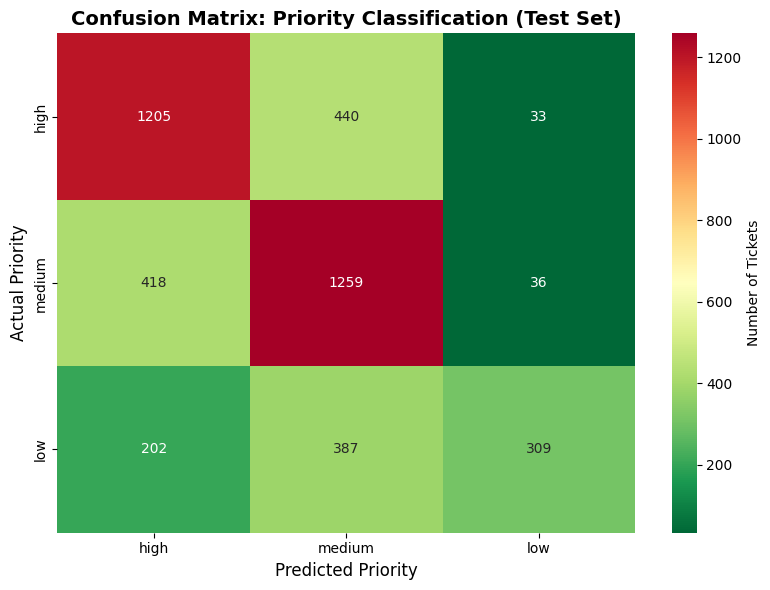

✅ Confusion matrix saved to: processed/confusion_matrix_priority.png

=== CRITICAL ERROR ANALYSIS ===
High → Low (costly): 33 tickets (2.0% of high priority)
Low → High (less costly): 202 tickets (22.5% of low priority)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions on test set
y_pred_priority_test = priority_champion_model.predict(X_test_tfidf)

# Priority labels in order
priority_labels = ['high', 'medium', 'low']

# Create confusion matrix
cm_priority = confusion_matrix(y_priority_test, y_pred_priority_test, labels=priority_labels)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm_priority, 
            annot=True, 
            fmt='d', 
            cmap='RdYlGn_r',
            xticklabels=priority_labels,
            yticklabels=priority_labels,
            ax=ax,
            cbar_kws={'label': 'Number of Tickets'})

ax.set_title('Confusion Matrix: Priority Classification (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Priority', fontsize=12)
ax.set_ylabel('Actual Priority', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\data\processed\confusion_matrix_priority.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Confusion matrix saved to: processed/confusion_matrix_priority.png")

# Critical error analysis
print("\n=== CRITICAL ERROR ANALYSIS ===")
high_to_low = cm_priority[0, 2]  # high → low
total_high = cm_priority[0, :].sum()
print(f"High → Low (costly): {high_to_low} tickets ({high_to_low/total_high*100:.1f}% of high priority)")

low_to_high = cm_priority[2, 0]  # low → high
total_low = cm_priority[2, :].sum()
print(f"Low → High (less costly): {low_to_high} tickets ({low_to_high/total_low*100:.1f}% of low priority)")

### Top 20 Most Important Features

#### Purpose
Show which words most strongly influence department predictions.

#### How to Read
- Longer bars = more important for classification
- Words like "server", "payment", "outage" should appear at top
- Validates that model learns meaningful patterns

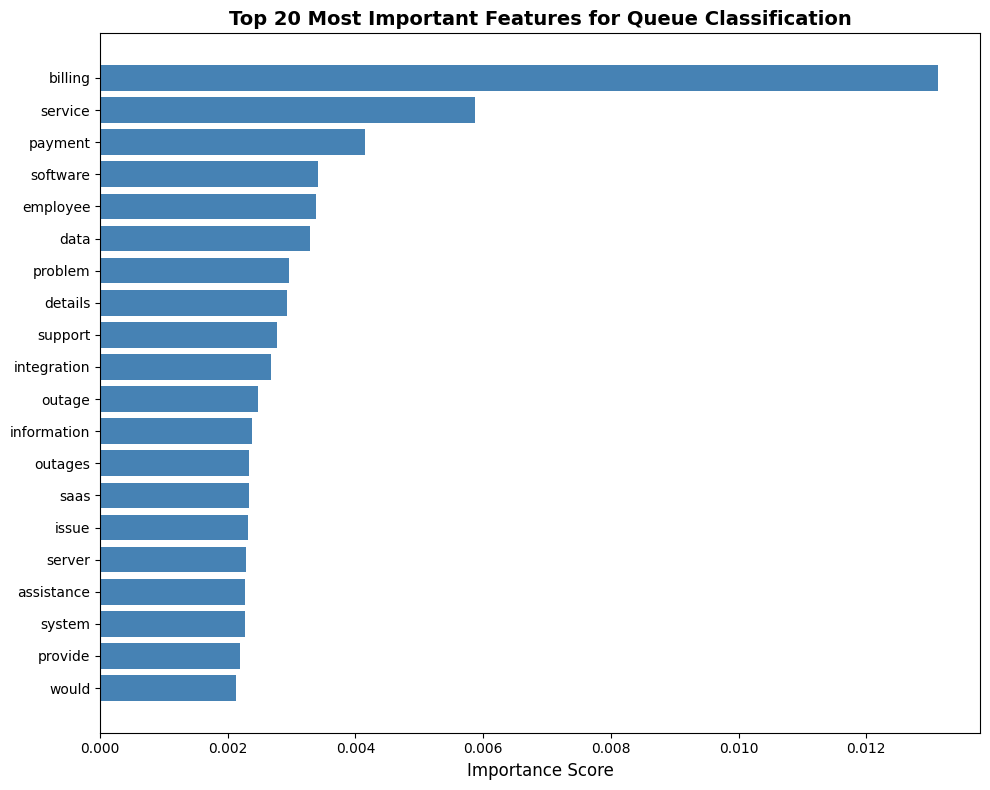

✅ Feature importance saved to: processed/feature_importance_queue.png

=== TOP 10 FEATURES ===
  billing: 0.0131
  service: 0.0059
  payment: 0.0042
  software: 0.0034
  employee: 0.0034
  data: 0.0033
  problem: 0.0030
  details: 0.0029
  support: 0.0028
  integration: 0.0027


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importance from Random Forest
feature_importance = champion_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Create dataframe and sort
feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Take top 20
top_features = feature_df.head(20)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 20 Most Important Features for Queue Classification', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest at top

plt.tight_layout()
plt.savefig(r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_02\data\processed\feature_importance_queue.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Feature importance saved to: processed/feature_importance_queue.png")

print("\n=== TOP 10 FEATURES ===")
for i, row in top_features.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

### Feature Importance Analysis

#### Top Features by Department Signal

| Feature | Importance | Associated Department |
|---------|------------|----------------------|
| billing | 0.0131 | Billing and Payments |
| service | 0.0059 | Service Outages / Customer Service |
| payment | 0.0042 | Billing and Payments |
| software | 0.0034 | Technical Support / IT Support |
| employee | 0.0034 | Human Resources |
| data | 0.0033 | Technical Support / Product Support |
| problem | 0.0030 | Technical Support |
| details | 0.0029 | General Inquiry / Customer Service |
| support | 0.0028 | Cross-department (lower weight) |
| integration | 0.0027 | Product Support |

#### Validation

The model has learned meaningful patterns:
- **billing**, **payment** → Billing department
- **employee** → Human Resources
- **software**, **problem** → Technical Support
- **outage** → Service Outages (appears in full list)

#### Business Value

These features can be used to:
1. Explain predictions to stakeholders
2. Validate model behavior matches business logic
3. Identify new patterns in customer tickets

#### Next Step

Proceed to final Model Card documentation.